In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math 
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder


KeyboardInterrupt: 

**Airbnb en Nueva York**
Una empresa ha recolectado la información del alquiler de viviendas en Nueva York a través de la aplicación Airbnb durante el año 2019. Este conjunto de datos se utilizó para entrenar modelos de Machine Learning durante ese año, en una competición en abierto.

Ahora lo utilizaremos para llevar a cabo un estudio acerca de las variables que componen el dataset a fin de comprenderlo y obtener conclusiones sobre él.

# Paso 1: Carga del conjunto de datos
Puedes descargar el conjunto de datos directamente desde Kaggle.com o en el siguiente enlace: https://breathecode.herokuapp.com/asset/internal-link?id=927&path=AB_NYC_2019.csv. Almacena los datos en crudo en la carpeta ./data/raw.

# Paso 2: Realiza un EDA completo
Este paso es vital para asegurar que nos quedamos con las variables estrictamente necesarias y eliminamos las que no son relevantes o no aportan información. Utiliza el Notebook de ejemplo que trabajamos y adáptalo a este caso de uso.

Asegúrate de dividir convenientemente el conjunto de datos en train y test como hemos visto en la lección.

# Paso 3: Guarda el conjunto de datos procesado
Después del EDA puedes guardar los datos en la carpeta ./data/processed. Asegúrate de agregar la carpeta de los datos en el .gitignore. Los datos al igual que los modelos no se deben subir a git.

In [ ]:
df = pd.read_csv("../data/raw/AB_NYC_2019.csv") 
df


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2


Generamos los datos relevantes del Data frame 

In [ ]:
df.head() 

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [ ]:
df.shape

(48895, 16)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [ ]:
df.isna().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

Podemos observar que la variables name, host_name, last_review y reviews_per_month tienen valores nulos 

In [ ]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [ ]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='str')

Evaluemos las posibles 
variables categoricas 

In [ ]:
df.select_dtypes(include=['object']).columns


/tmp/ipykernel_30053/2318984544.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include=['object']).columns


Index(['name', 'host_name', 'neighbourhood_group', 'neighbourhood',
       'room_type', 'last_review'],
      dtype='str')

In [ ]:
df['room_type'].unique()


<StringArray>
['Private room', 'Entire home/apt', 'Shared room']
Length: 3, dtype: str

ELIMINAMOS VALORES NULOS QUE NOS AFECTEN 

In [ ]:
df = df.fillna(0)
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0,0.00,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [ ]:
print(df.isnull().sum())

id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64


# Analisis  univariable 

In [ ]:
df[df[['longitude', 'latitude' ]].duplicated(keep=False)].sort_values(['longitude', 'latitude'])

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
7794,5918053,1 Quiet Private Room in Heart of Soho!,2938204,Veronica,Manhattan,SoHo,40.72741,-74.00178,Private room,142,5,8,2017-12-21,0.16,1,188
12313,9513278,Sunny and chic SoHo apartment,49293535,Aleksandra,Manhattan,SoHo,40.72741,-74.00178,Entire home/apt,185,3,2,2016-05-26,0.05,1,0
10947,8444227,Private Room in Heart of Soho,44457589,Joel,Manhattan,SoHo,40.72607,-74.00166,Private room,95,1,152,2019-06-04,3.34,2,9
38490,30290307,Beautiful Central 2 Bedroom in Soho!,227498924,Alex,Manhattan,SoHo,40.72607,-74.00166,Entire home/apt,299,4,2,2019-05-18,0.32,1,156
2575,1336223,"Safe, Sunny, Quiet Chelsea Apt has Washer/Dryer",7245581,Michael,Manhattan,Chelsea,40.74913,-73.99575,Entire home/apt,93,39,25,2019-05-13,0.35,19,245
47521,35790090,Authentic Chelsea Studio Loft,89629761,Juan,Manhattan,Chelsea,40.74913,-73.99575,Entire home/apt,89,2,0,0,0.00,1,37
30053,23136074,So nice and close to everything.,171939378,Jose,Manhattan,Hell's Kitchen,40.75584,-73.99559,Entire home/apt,200,3,2,2018-05-13,0.14,2,0
36076,28666578,Large Cozy Bedroom 10 mins from Times Sq. 33C3,190921808,John,Manhattan,Hell's Kitchen,40.75584,-73.99559,Private room,120,7,4,2019-04-16,0.44,47,365
11913,9277608,Soho 3BR/2BA Everything is just outside your d...,42047615,Jonathan & Nancy,Manhattan,Nolita,40.72347,-73.99302,Entire home/apt,650,3,130,2019-06-05,3.11,2,235
28991,22316496,Cozy private room in the heart of Nolita / Soho,8726000,Larasati,Manhattan,Nolita,40.72347,-73.99302,Private room,70,2,2,2019-02-25,0.11,1,0


Eliminamos las variables que no nos hacen falta 


In [ ]:

data = df.copy()

data.drop(['id','name','host_name', 'host_id','last_review'],axis=1,inplace=True)



In [ ]:
data

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.00,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...
48890,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,0.00,2,9
48891,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,0.00,2,36
48892,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,0.00,1,27
48893,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,0.00,6,2


In [ ]:
#Revisamos si hay precios a cero ¿por qué sería? 
data[data['price'] == 0]

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
23161,Brooklyn,Bedford-Stuyvesant,40.69023,-73.95428,Private room,0,4,1,0.05,4,28
25433,Bronx,East Morrisania,40.83296,-73.88668,Private room,0,2,55,2.56,4,127
25634,Brooklyn,Bushwick,40.69467,-73.92433,Private room,0,2,16,0.71,5,0
25753,Brooklyn,Greenpoint,40.72462,-73.94072,Private room,0,2,12,0.53,2,0
25778,Brooklyn,Williamsburg,40.70838,-73.94645,Entire home/apt,0,5,3,0.15,1,73
25794,Brooklyn,Bedford-Stuyvesant,40.68173,-73.91342,Private room,0,1,93,4.28,6,176
25795,Brooklyn,Bedford-Stuyvesant,40.68279,-73.91170,Private room,0,1,95,4.37,6,232
25796,Brooklyn,Bedford-Stuyvesant,40.68258,-73.91284,Private room,0,1,95,4.35,6,222
26259,Manhattan,Murray Hill,40.75091,-73.97597,Entire home/apt,0,3,0,0.00,1,0
26841,Brooklyn,Bushwick,40.69211,-73.90670,Shared room,0,30,2,0.11,6,333


Se podrian eliminar los valores a cero ya que al tener 14 datos de 48895 no deberia afectar en los calculos. O poner los valores precio con la media de todos los valores

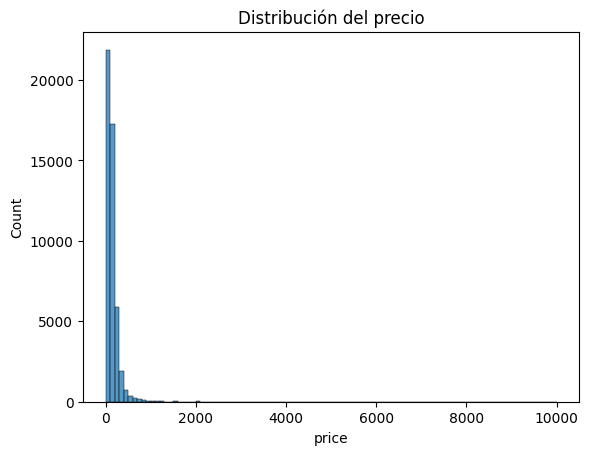

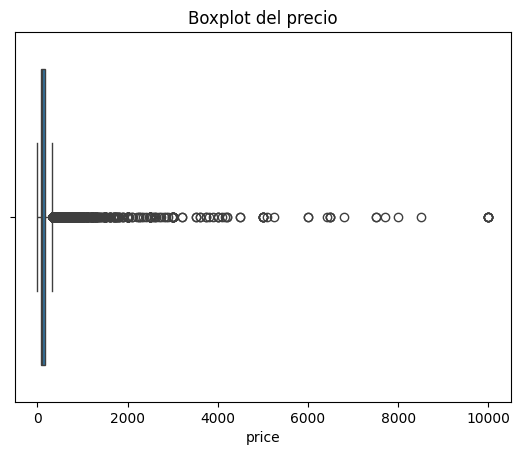

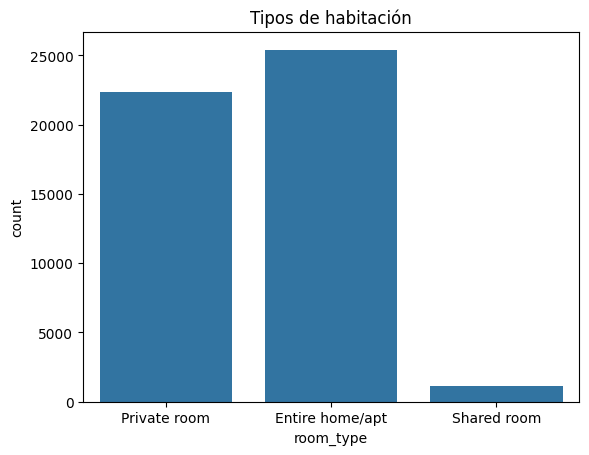

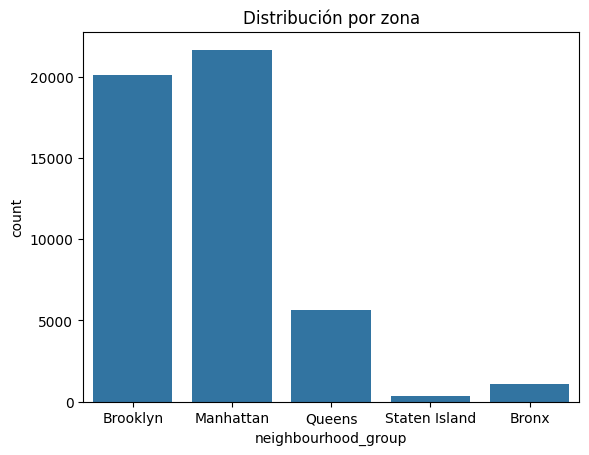

In [ ]:
# Distribución del precio
plt.figure()
sns.histplot(data['price'], bins=100)
plt.title('Distribución del precio')
plt.show()

# Boxplot del precio
plt.figure()
sns.boxplot(x=data['price'])
plt.title('Boxplot del precio')
plt.show()

# Conteo por tipo de habitación
plt.figure()
sns.countplot(x='room_type', data=data)
plt.title('Tipos de habitación')
plt.show()

# Conteo por zona
plt.figure()
sns.countplot(x='neighbourhood_group', data=data)
plt.title('Distribución por zona')
plt.show()

Como podemos apreciar, en la gráfica de dsitribución de precios podemos ver que hay una cola grande a la derecha lo que indica que hay un outlier que afecta a los datos que estamos mostrando. 

En el diagrama de caja se puede afirmar que tenemos valores atipicos

En los tipos de habitación el entire home es el que predomina.

## Variables numéricas:

price, minimum_nights, number_of_reviews, reviews_per_month, calculated_host_listings_count, availability_365, latitude, longitude

## Variables categóricas:

neighbourhood_group, neighbourhood, room_type 

In [ ]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             48895 non-null  str    
 1   neighbourhood                   48895 non-null  str    
 2   latitude                        48895 non-null  float64
 3   longitude                       48895 non-null  float64
 4   room_type                       48895 non-null  str    
 5   price                           48895 non-null  int64  
 6   minimum_nights                  48895 non-null  int64  
 7   number_of_reviews               48895 non-null  int64  
 8   reviews_per_month               48895 non-null  float64
 9   calculated_host_listings_count  48895 non-null  int64  
 10  availability_365                48895 non-null  int64  
dtypes: float64(3), int64(5), str(3)
memory usage: 4.1 MB


In [ ]:
data.describe()

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000
mean,40.728949,-73.952170,152.720687,7.029962,23.274466,1.090910,7.143982,112.781327
std,0.054530,0.046157,240.154170,20.510550,44.550582,1.597283,32.952519,131.622289
min,40.499790,-74.244420,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,40.690100,-73.983070,69.000000,1.000000,1.000000,0.040000,1.000000,0.000000
50%,40.723070,-73.955680,106.000000,3.000000,5.000000,0.370000,1.000000,45.000000
75%,40.763115,-73.936275,175.000000,5.000000,24.000000,1.580000,2.000000,227.000000
max,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


# Analisis  bivariable 

(0.0, 1200.0)

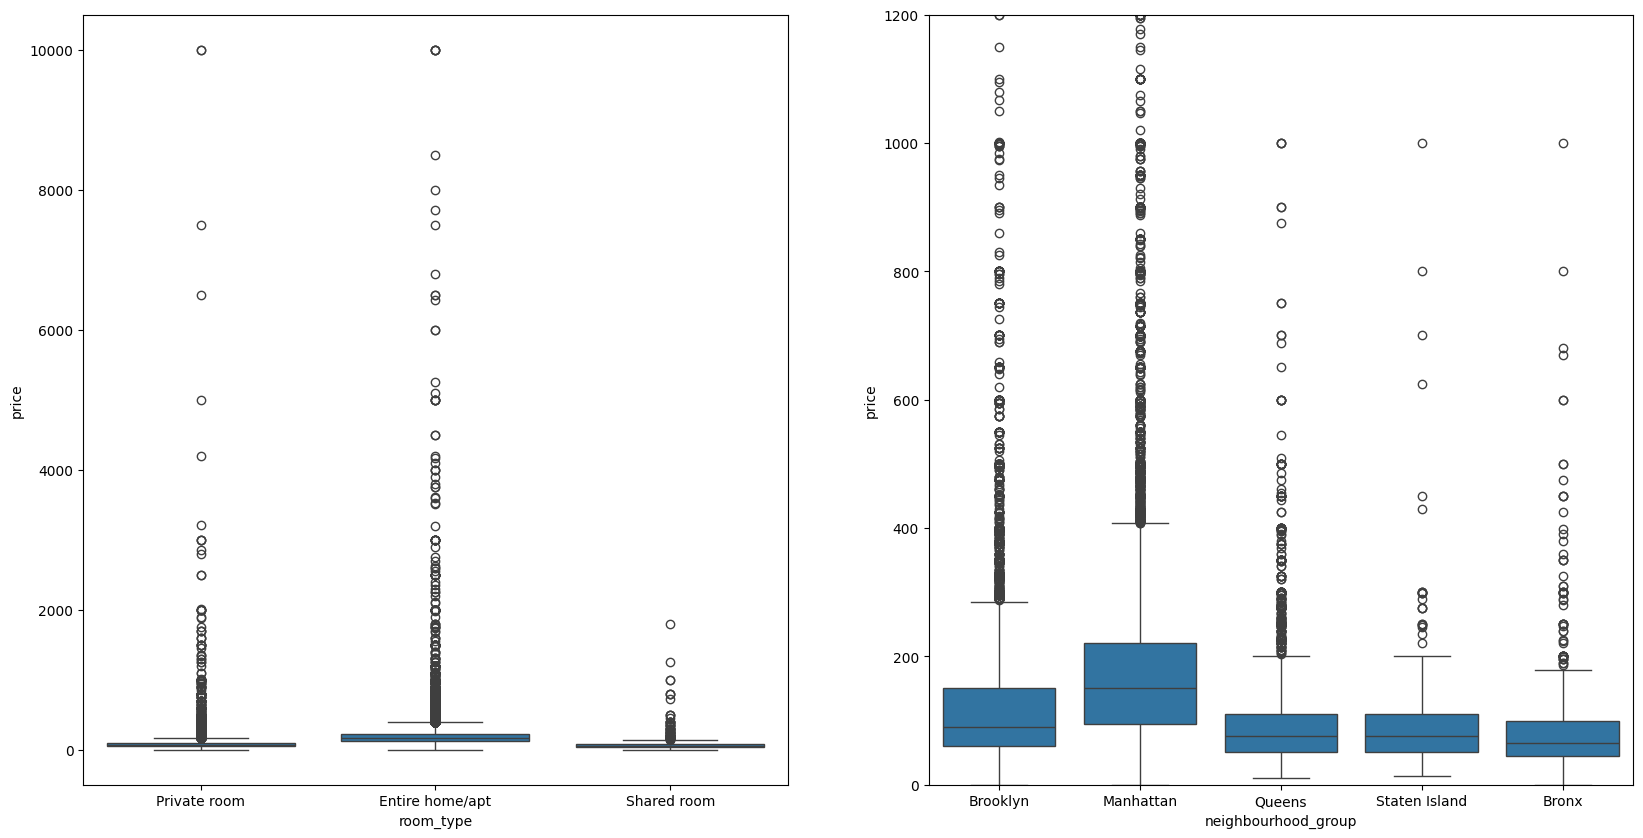

In [ ]:
fig, axis = plt.subplots(1, 2, figsize=(20, 10))
sns.boxplot(data=data, y='price', x = 'room_type', ax=axis[0])
sns.boxplot(data=data, y='price', x = 'neighbourhood_group', ax=axis[1] )
plt.ylim(0, 1200)

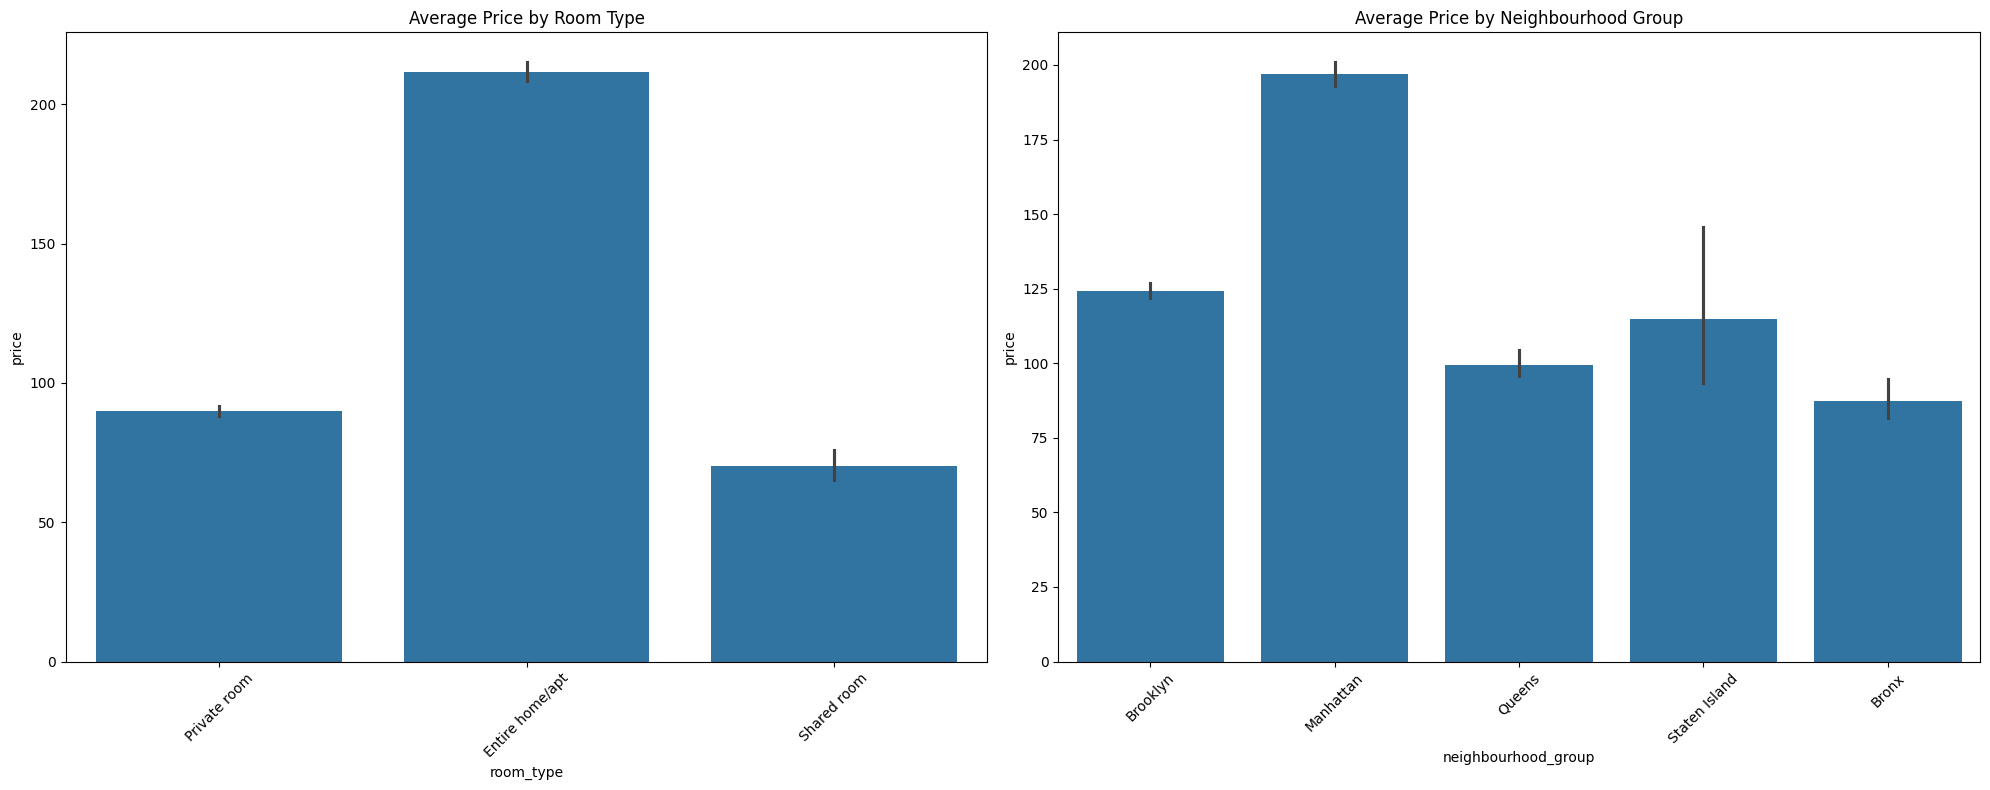

In [ ]:
fig, axis = plt.subplots(1, 2, figsize=(20, 8))

sns.barplot(data=data, x='room_type', y='price', ax=axis[0], estimator=np.mean)
axis[0].set_title('Average Price by Room Type')
axis[0].tick_params(axis='x', rotation=45)

sns.barplot(data=data, x='neighbourhood_group', y='price', ax=axis[1], estimator=np.mean)
axis[1].set_title('Average Price by Neighbourhood Group')
axis[1].tick_params(axis='x', rotation=45)

plt.tight_layout()

Conclusión:

- El entire home es el que mas costos puede llegar a tener en comparacion con un shared room 
- existen muchos valores atipicos 
- manhattan es el barrio mas costoso entre los 5 anañlizados 

## Outliers


Verificamos el valor atipico que tiene precio 

=== PRICE ===
count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64
Precios = 0: 11
Precios > 1000: 239
Precios > 5000: 20


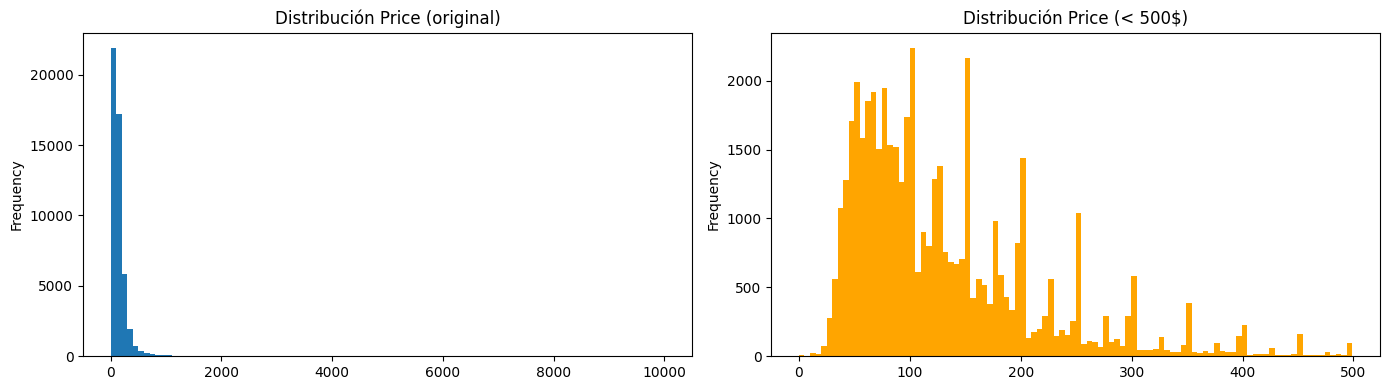

In [ ]:
print('=== PRICE ===')
price_stats = data['price'].describe()
print(price_stats)
print(f'Precios = 0: {(data["price"] == 0).sum()}')
print(f'Precios > 1000: {(data["price"] > 1000).sum()}')
print(f'Precios > 5000: {(data["price"] > 5000).sum()}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
data['price'].plot(kind='hist', bins=100, ax=axes[0], title='Distribución Price (original)')
data[data['price'] < 500]['price'].plot(kind='hist', bins=100, ax=axes[1], title='Distribución Price (< 500$)', color='orange')
plt.tight_layout()
plt.show()

In [ ]:
price_iqr = price_stats["75%"] - price_stats["25%"]
#LIMITE SUPERIOR == Q3 + 1.5*IQR
upper_limit = price_stats["75%"] + 1.5 * price_iqr
#LIMITE INFERIOR == Q1 + 1.5*IQR
lower_limit = price_stats["25%"] - 1.5 * price_iqr

upper_limit, lower_limit

(np.float64(334.0), np.float64(-90.0))

(0.0, 340.0)

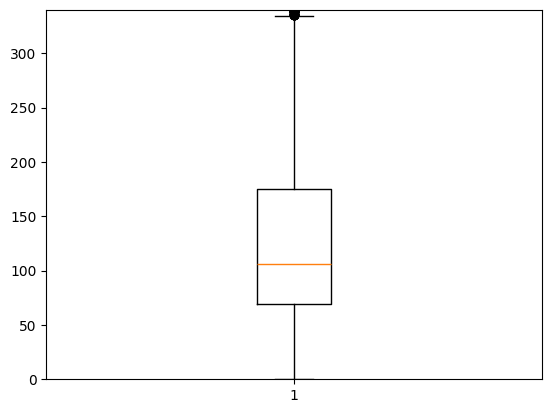

In [ ]:
plt.boxplot(x = data['price'])
plt.ylim(0, 340)

In [ ]:
data[data.price > 334]

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
61,Manhattan,Chelsea,40.74623,-73.99530,Entire home/apt,375,180,5,0.12,1,180
85,Brooklyn,Brooklyn Heights,40.69723,-73.99268,Entire home/apt,800,1,25,0.24,1,7
103,Manhattan,West Village,40.73096,-74.00319,Entire home/apt,500,4,46,0.55,2,243
114,Manhattan,East Village,40.72540,-73.98157,Entire home/apt,350,2,7,0.06,4,298
121,Brooklyn,South Slope,40.66499,-73.97925,Entire home/apt,400,2,16,0.24,2,216
...,...,...,...,...,...,...,...,...,...,...,...
48758,Queens,Long Island City,40.75508,-73.93258,Entire home/apt,350,2,0,0.00,1,364
48833,Manhattan,Financial District,40.70605,-74.01042,Entire home/apt,475,2,0,0.00,1,64
48839,Brooklyn,Sheepshead Bay,40.59866,-73.95661,Private room,800,1,0,0.00,1,23
48842,Manhattan,Chelsea,40.75204,-74.00292,Entire home/apt,350,1,0,0.00,1,9


De estos outliers podríamos hacer varias cosas, podríamos no tenerlos en cuenta, podríamos hacer una winsorización para poder reemplazar valores percentiles. 

In [ ]:
# Paso 1: Eliminar precio = 0 (errores claros, solo 11 filas)
data = data[data['price'] > 0].copy()
print(f'Filas tras eliminar price=0: {len(data):,}')

# Paso 2: Capping de price al percentil 99 (Winsorización)
# Razón: precios de 10.000$ son válidos pero extremos. Mejor acotar que eliminar.
p99_price = data['price'].quantile(0.99)
print(f'Percentil 99 de price: ${p99_price}')
data['price'] = data['price'].clip(upper=p99_price)
print(f'Price máximo tras capping: ${data["price"].max()}')

Filas tras eliminar price=0: 48,884
Percentil 99 de price: $799.0
Price máximo tras capping: $799


In [ ]:
# --- MINIMUM_NIGHTS ---
print('=== MINIMUM_NIGHTS ===')
print(data['minimum_nights'].describe())
print(f'Valores > 365 días: {(data["minimum_nights"] > 365).sum()}')

# Un mínimo de 1250 noches no tiene sentido para Airbnb — aplicamos capping al p99
p99_nights = data['minimum_nights'].quantile(0.99)
print(f'Percentil 99 de minimum_nights: {p99_nights}')
data['minimum_nights'] = data['minimum_nights'].clip(upper=p99_nights)
print(f'minimum_nights máximo tras capping: {data["minimum_nights"].max()}')

=== MINIMUM_NIGHTS ===
count    48884.000000
mean         7.029887
std         20.512224
min          1.000000
25%          1.000000
50%          3.000000
75%          5.000000
max       1250.000000
Name: minimum_nights, dtype: float64
Valores > 365 días: 14
Percentil 99 de minimum_nights: 45.0
minimum_nights máximo tras capping: 45


# Visualización de outliers con boxplots

In [ ]:
numeric_cols = ['latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count',
       'availability_365']

In [1]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    df.boxplot(column=col, ax=axes[i])
    axes[i].set_title(col)
plt.suptitle('Boxplots de Variables Numéricas (tras capping)', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

## Correlacion 

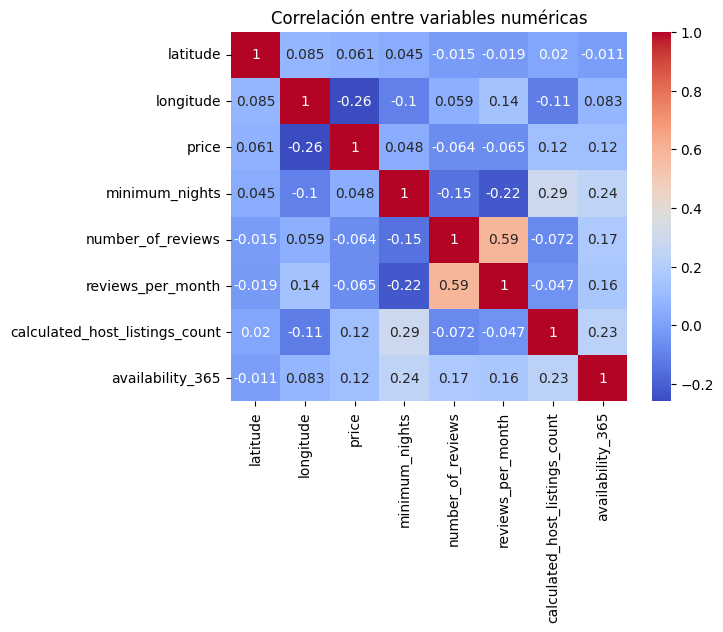

In [ ]:
plt.figure()
corr = data.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlación entre variables numéricas')
plt.show()

la variable revies per month tiene una correlacion directa positiva con los number of reviews. Aunque no existen muchas correlaciones directas numericas 

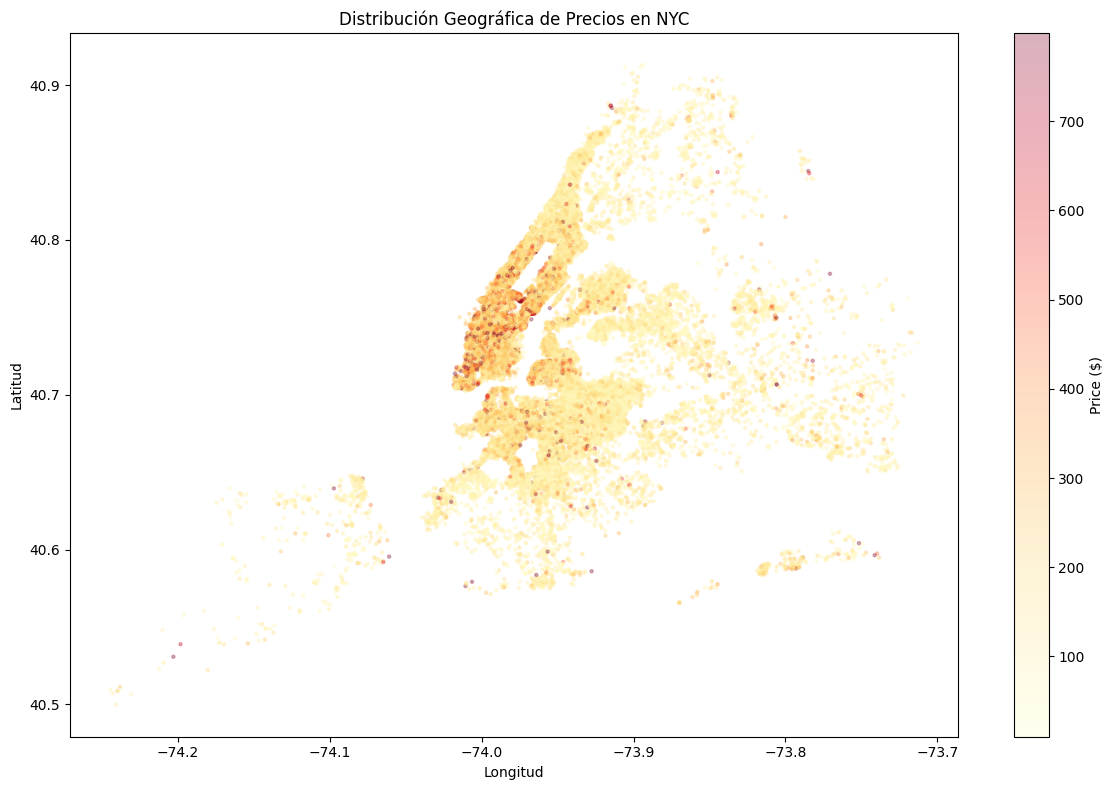

In [ ]:
# Distribución geográfica de precios (scatter plot)
plt.figure(figsize=(12, 8))
scatter = plt.scatter(data['longitude'], data['latitude'],
                      c=data['price'], cmap='YlOrRd', alpha=0.3, s=5)
plt.colorbar(scatter, label='Price ($)')
plt.title('Distribución Geográfica de Precios en NYC')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.tight_layout()
plt.show()

### Transformación de datos 

- Encoding de las variables categoricas

Para que el modelo pueda procesar las variables categóricas:
- `room_type` (3 categorías): **One-Hot Encoding** — baja cardinalidad.
- `neighbourhood_group` (5 categorías): **One-Hot Encoding** — baja cardinalidad.
- `neighbourhood` (221 categorías): **Label Encoding** o **Target Encoding** — alta cardinalidad. Usamos Label Encoding por simplicidad. Para modelos lineales se recomendaría Target Encoding.

> ⚠️ `latitude` y `longitude` las conservamos como numéricas — ya están en formato correcto.

In [ ]:
variable_categorica = ['neighbourhood_group', 'room_type', 'neighbourhood']

df_processed = data.copy()

# One-Hot Encoding para baja cardinalidad
df_processed = pd.get_dummies(df_processed,
                               columns=['room_type', 'neighbourhood_group'],
                               drop_first=False)  # drop_first=True si usamos regresión lineal

# Label Encoding para neighbourhood (alta cardinalidad)
le = LabelEncoder()
df_processed['neighbourhood_encoded'] = le.fit_transform(df_processed['neighbourhood'])
df_processed.drop(columns=['neighbourhood'], inplace=True)

print(f'Shape tras encoding: {df_processed.shape}')
print(f'Columnas: {df_processed.columns.tolist()}')
df_processed

Shape tras encoding: (48895, 17)
Columnas: ['latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'room_type_Entire home/apt', 'room_type_Private room', 'room_type_Shared room', 'neighbourhood_group_Bronx', 'neighbourhood_group_Brooklyn', 'neighbourhood_group_Manhattan', 'neighbourhood_group_Queens', 'neighbourhood_group_Staten Island', 'neighbourhood_encoded']


,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,room_type_Entire home/apt,room_type_Private room,room_type_Shared room,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,neighbourhood_encoded
0,40.64749,-73.97237,149,1,9,0.21,6,365,False,True,False,False,True,False,False,False,108
1,40.75362,-73.98377,225,1,45,0.38,2,355,True,False,False,False,False,True,False,False,127
2,40.80902,-73.94190,150,3,0,0.00,1,365,False,True,False,False,False,True,False,False,94
3,40.68514,-73.95976,89,1,270,4.64,1,194,True,False,False,False,True,False,False,False,41
4,40.79851,-73.94399,80,10,9,0.10,1,0,True,False,False,False,False,True,False,False,61
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,40.67853,-73.94995,70,2,0,0.00,2,9,False,True,False,False,True,False,False,False,13
48891,40.70184,-73.93317,40,4,0,0.00,2,36,False,True,False,False,True,False,False,False,28
48892,40.81475,-73.94867,115,10,0,0.00,1,27,True,False,False,False,False,True,False,False,94
48893,40.75751,-73.99112,55,1,0,0.00,6,2,False,False,True,False,False,True,False,False,95


# Hacemos el split 

**Ratio:** 80% train / 20% test — estándar para datasets de tamaño medio (~48k filas).

**`random_state=42`** — para reproducibilidad.

**`stratify`** — no aplica para regresión (precio es continuo). Si fuera clasificación (por ejemplo, rango de precio), sí lo usaríamos.

In [ ]:
X = df_processed.drop(columns=['price'])
y = df_processed['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'X_train: {X_train.shape} | y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape} | y_test:  {y_test.shape}')

# Verificar que la distribución de y es similar en train y test
print(f'\nMedia price train: ${y_train.mean():.2f} | test: ${y_test.mean():.2f}')
print(f'Mediana price train: ${y_train.median():.2f} | test: ${y_test.median():.2f}')

X_train: (39116, 16) | y_train: (39116,)
X_test:  (9779, 16) | y_test:  (9779,)

Media price train: $153.75 | test: $148.60
Mediana price train: $107.00 | test: $104.00


In [ ]:
import os
os.makedirs('./data/processed', exist_ok=True)

# Guardar los conjuntos procesados
X_train.to_csv('./data/processed/X_train.csv', index=False)
X_test.to_csv('./data/processed/X_test.csv', index=False)
y_train.to_csv('./data/processed/y_train.csv', index=False, header=True)
y_test.to_csv('./data/processed/y_test.csv', index=False, header=True)

# Guardar también el dataset completo procesado por si se necesita
df_processed.to_csv('./data/processed/airbnb_nyc_clean.csv', index=False)

print('✅ Archivos guardados en ./data/processed/')
print('   - X_train.csv')
print('   - X_test.csv')
print('   - y_train.csv')
print('   - y_test.csv')
print('   - airbnb_nyc_clean.csv')

✅ Archivos guardados en ./data/processed/
   - X_train.csv
   - X_test.csv
   - y_train.csv
   - y_test.csv
   - airbnb_nyc_clean.csv


In [ ]:
# .gitignore — añadir data/ para que no se suba a git
gitignore_content = """
# Datos — no subir a git
data/

# Modelos entrenados
models/

# Python
__pycache__/
*.pyc
.ipynb_checkpoints/
"""

with open('.gitignore', 'w') as f:
    f.write(gitignore_content)

print('.gitignore creado ✅')

.gitignore creado ✅
